# Archivo NetCDF

Vamos a abrir un tipo de archivo más "avanzado", con un formato que se llama NetCDF

Es un archivo que tiene tanto información espacial como temporal

In [1]:
# === Datos ===
DATA_URL = "https://raw.githubusercontent.com/aaleta/cex_2026/main/1_obtencion/data/"

import os, urllib.request
def datos(nombre):
    if not os.path.exists(nombre) and DATA_URL:
        urllib.request.urlretrieve(DATA_URL + nombre, nombre)
    if not os.path.exists(nombre):
        raise FileNotFoundError(f"Falta '{nombre}': súbelo a Colab o define DATA_URL")
    return nombre

for _f in ['data_stream-oper_stepType-instant.nc']:
    datos(_f)
print('Datos listos:', 'data_stream-oper_stepType-instant.nc')

Datos listos: data_stream-oper_stepType-instant.nc


## Abrimos el archivo

Con la libreria 'xarray'

In [2]:
import xarray as xr

# Abrimos el dataset
ds = xr.open_dataset('data_stream-oper_stepType-instant.nc')

# Y lo mostramos por pantalla
display(ds)

<xarray.Dataset> Size: 187MB
Dimensions:     (valid_time: 17544, latitude: 41, longitude: 65)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 140kB 2024-01-01 ... 2025-12-31T2...
  * latitude    (latitude) float64 328B 45.0 44.75 44.5 ... 35.5 35.25 35.0
  * longitude   (longitude) float64 520B -11.0 -10.75 -10.5 ... 4.5 4.75 5.0
    number      int64 8B ...
    expver      (valid_time) <U4 281kB ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 187MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-11T09:24 GRIB to CDM+CF via cfgrib-0.9.1...

Vemos varias cosas aquí:

- Una serie de metadatos en "Attributes".
- En "dimensions" vemos la malla de datos que manejamos. Tenemos:
    - 41 divisiones para la latitud
    - 65 para la longitud
    - 17544 para el tiempo
- En "coordinates" tenemos los valores concretos que corresponden a esas divisiones de latitud, longitud y tiempo
- En data variables tenemos los valores concretos que estamos apuntando para cada tupla (tiempo, latitud, longitud). Podríamos tener varias variables aquí, en este caso solo tenemos una llamada "t2m". El nombre no es especialmente explicativo, pero ya os digo yo que se refiere a Temperatura medida a 2 metros sobre el suelo. NOTA: Lo podian haber explicado en los metadatos.

En resumen, tenemos una especie de mapa "dinámico" de la temperatura, una especie de "video" con 17544 fotogramas.

## Coordenadas

### Exploremos el tiempo

Vamos a ver primero que periodo de tiempo tenemos aquí

In [3]:
if 'valid_time' in ds.coords:
    start_time = ds['valid_time'].min().values
    end_time = ds['valid_time'].max().values
    print(f"El archivo abarca desde: {start_time} hasta: {end_time}")
else:
    print("No se encontró una coordenada de tiempo ('valid_time') en el archivo.")

El archivo abarca desde: 2024-01-01T00:00:00.000000000 hasta: 2025-12-31T23:00:00.000000000


... y cual es la frecuencia

In [5]:
if 'valid_time' in ds.coords:
    # Calculate the time differences between consecutive steps
    time_diffs = ds['valid_time'].diff(dim='valid_time')

    # Get the most frequent time difference (the mode)
    # Convert to a pandas Series to use value_counts().idxmax()
    frequency = time_diffs.to_series().value_counts().idxmax()

    print(f"La frecuencia de los datos es: {frequency}")
else:
    print("No se encontró una coordenada de tiempo ('valid_time') en el archivo.")

La frecuencia de los datos es: 0 days 01:00:00


Tenemos datos horarios.

### Exploremos el espacio

In [6]:
print("Coordenadas y sus rangos:")
for coord_name in ds.coords:
    # Skip 'valid_time' as it was already handled
    if coord_name == 'valid_time':
        continue

    coord_data = ds[coord_name]
    if coord_data.ndim == 1: # Only display ranges for 1D coordinates
        min_val = coord_data.min().values
        max_val = coord_data.max().values
        print(f"  {coord_name}: desde {min_val} hasta {max_val}")
    else:
        print(f"  {coord_name}: (no 1D, no se muestra rango simple)")

Coordenadas y sus rangos:
  number: (no 1D, no se muestra rango simple)
  latitude: desde 35.0 hasta 45.0
  longitude: desde -11.0 hasta 5.0
  expver: desde 0001 hasta 0001


In [7]:
if 'latitude' in ds.coords and 'longitude' in ds.coords:
    lat_diff = ds['latitude'].diff(dim='latitude').mean().values
    lon_diff = ds['longitude'].diff(dim='longitude').mean().values
    print(f"La resolución espacial de latitud es: {lat_diff} grados")
    print(f"La resolución espacial de longitud es: {lon_diff} grados")
else:
    print("Las coordenadas de latitud o longitud no se encontraron en el archivo.")

La resolución espacial de latitud es: -0.25 grados
La resolución espacial de longitud es: 0.25 grados


Tanto en latitud como en longitud tengo una malla de 0.25 grados de resolución, que abarcan desde 35º hasta 45º en latitud y desde -11º hasta 5º en longitud.

Esto es una "bounding box" que contiene la Peninsula Ibérica básicamente

## Datos

Aunque me estoy adelantando a otras clases, vamos a ver un poco los datos que tenemos

### Evolución temporal

Promediando en todo el espacio, ¿cómo evoluciona la temperatura en el tiempo?

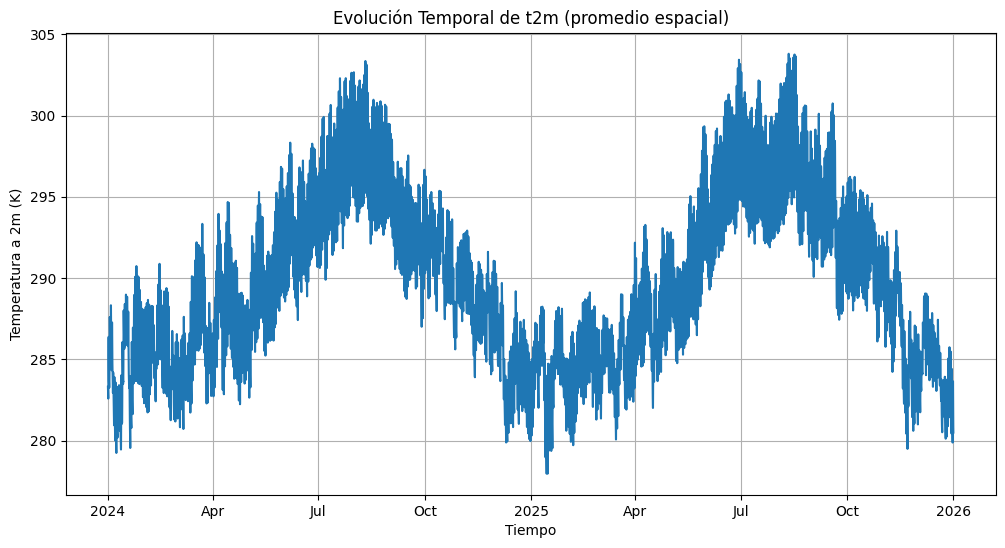

In [8]:
import matplotlib.pyplot as plt

# Calcular el promedio espacial de t2m
t2m_spatial_mean = ds['t2m'].mean(dim=['latitude', 'longitude'])

# Crear la gráfica de la evolución temporal
plt.figure(figsize=(12, 6))
t2m_spatial_mean.plot()
plt.title('Evolución Temporal de t2m (promedio espacial)')
plt.xlabel('Tiempo')
plt.ylabel('Temperatura a 2m (K)')
plt.grid(True)
plt.show()

### Evolución espacial

Para un momento temporal fijo, ¿cómo es ese mapa de temperaturas?

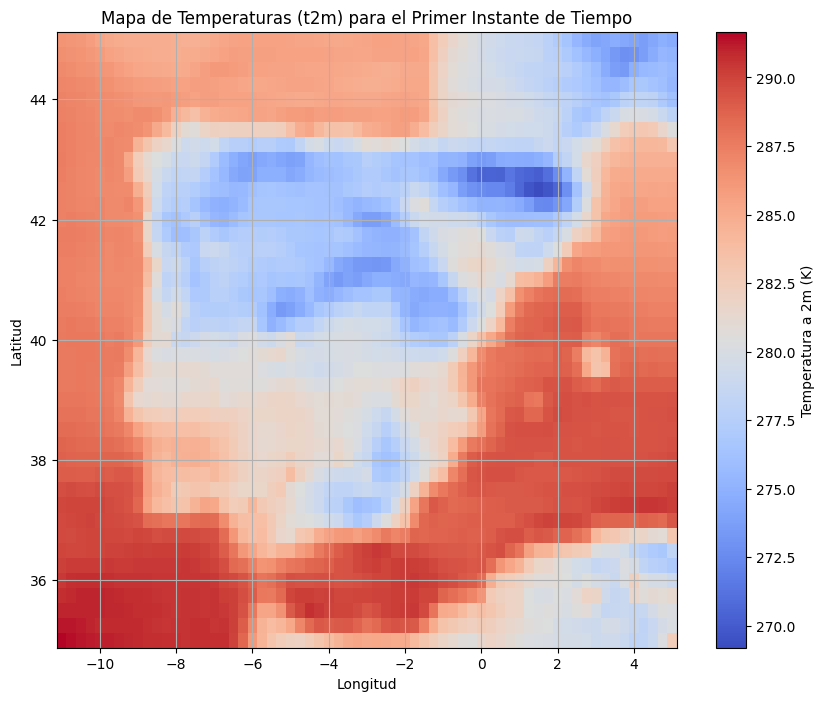

In [9]:
import matplotlib.pyplot as plt

# Seleccionar la variable t2m para el primer instante de tiempo
t2m_first_timestep = ds['t2m'].isel(valid_time=0)

# Crear el mapa de temperaturas
plt.figure(figsize=(10, 8))
t2m_first_timestep.plot(x='longitude', y='latitude', cmap='coolwarm', cbar_kwargs={'label': 'Temperatura a 2m (K)'})
plt.title('Mapa de Temperaturas (t2m) para el Primer Instante de Tiempo')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True)
plt.show()

Podemos también sacar varios fotogramas

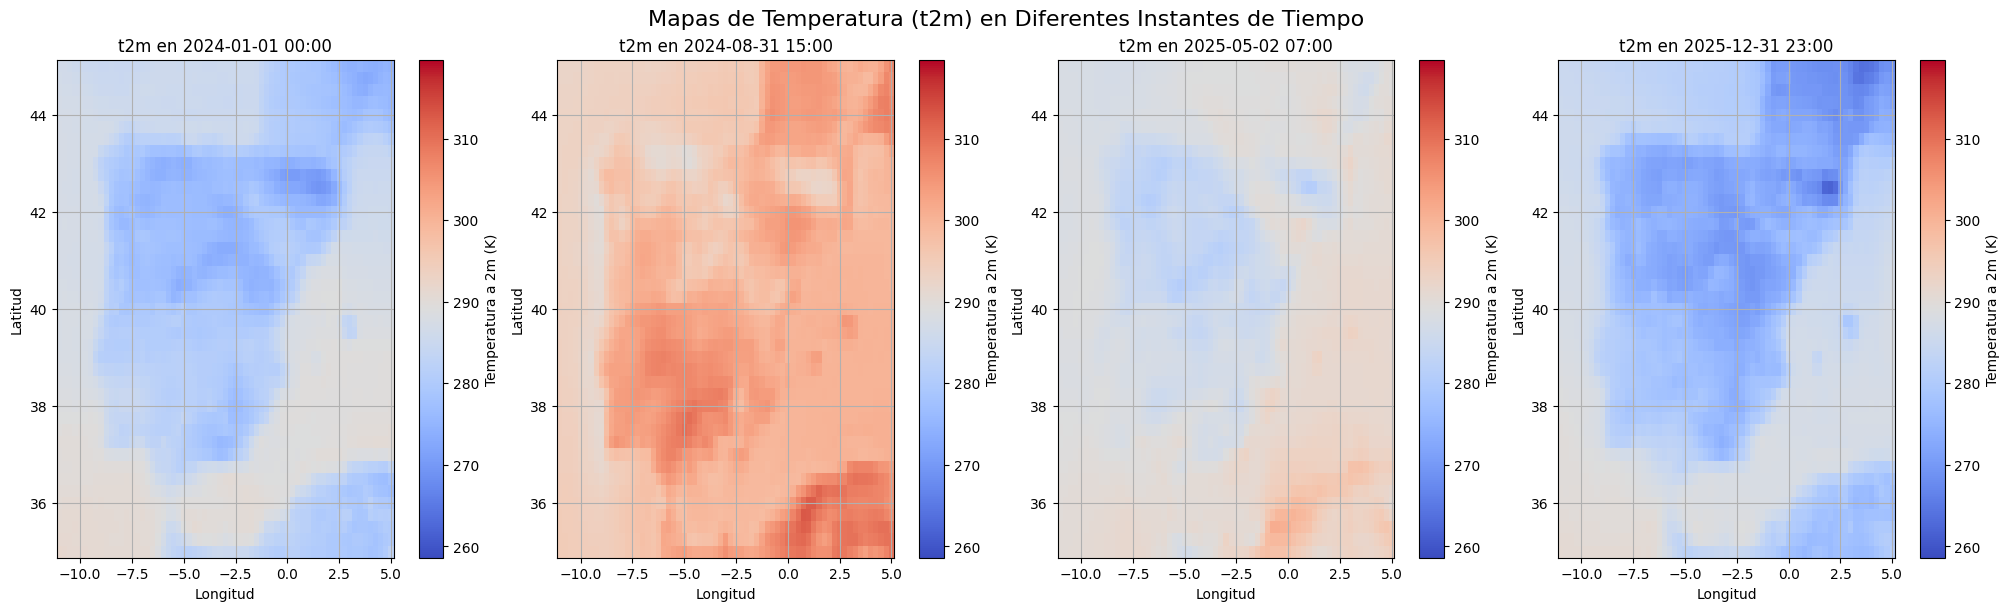

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Determinar la cantidad de pasos de tiempo y seleccionar algunos representativos
num_timesteps = len(ds['valid_time'])
# Seleccionar un máximo de 4 paneles para no sobrecargar la visualización
num_panels = min(4, num_timesteps)

# Seleccionar índices de tiempo equiespaciados
time_indices = np.linspace(0, num_timesteps - 1, num_panels, dtype=int)

# Calcular el rango global de t2m para una escala de color consistente
t2m_min = ds['t2m'].min().values
t2m_max = ds['t2m'].max().values

# Crear la figura y los subplots
fig, axes = plt.subplots(ncols=num_panels, figsize=(num_panels * 5, 6), constrained_layout=True)

# Ajustar si hay solo un panel (axes no sería un array)
if num_panels == 1:
    axes = [axes]

for i, idx in enumerate(time_indices):
    current_time_slice = ds.isel(valid_time=idx)

    # Plotear el mapa de t2m para el instante de tiempo actual
    current_time_slice['t2m'].plot(
        ax=axes[i],
        x='longitude',
        y='latitude',
        cmap='coolwarm',
        vmin=t2m_min,
        vmax=t2m_max, # Usar el rango global
        cbar_kwargs={'label': 'Temperatura a 2m (K)'}
    )
    axes[i].set_title(f"t2m en {current_time_slice['valid_time'].dt.strftime('%Y-%m-%d %H:%M').item()}")
    axes[i].set_xlabel('Longitud')
    axes[i].set_ylabel('Latitud')
    axes[i].grid(True)

plt.suptitle('Mapas de Temperatura (t2m) en Diferentes Instantes de Tiempo', fontsize=16)
plt.show()